# Pràctica Bloc III

## Introducció

L'objectiu d'aquesta pràctica és desenvolupar un model predictiu per classificar la satisfacció dels passatgers d'una aerolínia. A partir d'un conjunt de dades amb característiques demogràfiques, tipus de viatge i puntuacions de servei, s'entrenen i comparen cinc algorismes de classificació: Perceptró, Regressió Logística, SVM, Arbre de Decisió i Random Forest.

El treball s'estructura en quatre fases: (1) neteja i transformació de les dades, (2) anàlisi exploratori mitjançant clustering, (3) selecció d'hiperparàmetres i entrenament dels models, i (4) discussió crítica dels resultats.

## Càrrega de dades

Les dades estan dividides en dos fitxers CSV: entrenament i test. Aquesta partició predefinida permet avaluar el rendiment dels models sobre dades no vistes durant l'entrenament.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train_raw, test_raw = pd.read_csv("data/train.csv"), pd.read_csv("data/test.csv")
print(f"Dimensions del dataset (train): {train_raw.shape}")
print(f"Dimensions del dataset (test): {test_raw.shape}")
train_raw.head()

Dimensions del dataset (train): (103904, 25)
Dimensions del dataset (test): (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# Neteja i transformació de les dades

Aquest apartat comprèn l'eliminació de variables irrellevants per a la predicció i la transformació de les dades al format requerit pels algorismes d'aprenentatge automàtic.

Les columnes `Unnamed: 0` i `id` són identificadors únics de cada registre que no aporten capacitat predictiva sobre la satisfacció del passatger. Per tant, s'exclouen del conjunt de característiques.

In [4]:
# eliminam columnes que no aporten informació
ignore = { "Unnamed: 0", "id" }
train_raw.drop(columns=ignore, inplace=True, errors="ignore")
test_raw.drop(columns=ignore, inplace=True, errors="ignore")
print(train_raw.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


És imprescindible tractar els valors invàlids (`NaN`) abans de l'entrenament ja que qualsevol operació amb un valor invàlid resulta amb un altre valor invàlid. El primer pas consisteix en identificar quines columnes contenen aquests valors.

In [5]:
# comprovam quines columnes tenen valors invalids (NaNs)
train_raw.isna().sum() + test_raw.isna().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

L'única columna amb valors absents és *Arrival Delay in Minutes* amb 393 registres invàlids en total (dades de *train* i *test*). Al ser un nombre de registres relativament baix, es reemplaçen per la mitjana de la columna (imputació).

In [6]:
# reempleçam els NaNs per a la mitjana de la seva columna
nancol = "Arrival Delay in Minutes"
train_raw[nancol] = train_raw[nancol].fillna(train_raw[nancol].mean())
test_raw[nancol] = test_raw[nancol].fillna(test_raw[nancol].mean())
train_raw.isna().sum() + test_raw.isna().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

La tipologia de les variables del dataset es classifica en tres categories:

* **Variables categòriques**: conjunt d'etiquetes que classifiquen cada entrada
* **Variables de satisfacció**: escales en el rang $[0, 5]$
* **Variables numèriques**: valors continus o discrets

In [7]:
# columnes amb nivells de satisfacció [0, 5]
lvlcols = { "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking", "Gate location",
           "Food and drink", "Online boarding", "Seat comfort", "Inflight entertainment", "On-board service",
           "Leg room service", "Baggage handling", "Checkin service", "Inflight service", "Cleanliness" }
# obtenir les columnes sense valors numèrics -> columnes categòriques
catcols = set(train_raw.select_dtypes(exclude=[np.number]).columns)
# obtenir les columnes amb valor numèrics
numcols = set(train_raw.select_dtypes(include=[np.number]).columns)
# llevam les columnes de nivel de satisfacció per a tenir-ho organitzat en tres tipus 
numcols ^= lvlcols

numcols, lvlcols, catcols = map(list, (numcols, lvlcols, catcols))

lalign = 4
sep = "-" * 80

print("Columns with categoric values")
lmax = max(len(s) for s in catcols)
catvals = { col: list(train_raw[col].unique()) for col in catcols }
print("\n".join(" " * lalign + f"{col:{lmax}s} : {catvals[col]}" for col in catcols))
print(sep)

print("Columns with satisfaction level values [0-5]")
print("\n".join(" " * lalign + col for col in lvlcols))
print(sep)

print("Columns with numeric values")
print("\n".join(" " * lalign + col for col in numcols))

Columns with categoric values
    satisfaction   : ['neutral or dissatisfied', 'satisfied']
    Customer Type  : ['Loyal Customer', 'disloyal Customer']
    Type of Travel : ['Personal Travel', 'Business travel']
    Gender         : ['Male', 'Female']
    Class          : ['Eco Plus', 'Business', 'Eco']
--------------------------------------------------------------------------------
Columns with satisfaction level values [0-5]
    Gate location
    Seat comfort
    Inflight entertainment
    Baggage handling
    Food and drink
    Inflight service
    Online boarding
    Leg room service
    Inflight wifi service
    Checkin service
    Cleanliness
    On-board service
    Ease of Online booking
    Departure/Arrival time convenient
--------------------------------------------------------------------------------
Columns with numeric values
    Age
    Flight Distance
    Departure Delay in Minutes
    Arrival Delay in Minutes


Els algorismes d'aprenentatge requereixen entrada numèrica, per la qual cosa les variables categòriques es codifiquen mitjançant `OneHotEncoder`. Aquesta tècnica genera una columna binària per cada categoria, assignant 1 quan la categoria és present i 0 en cas contrari.

El paràmetre `drop="if_binary"` optimitza la representació: per a variables amb dues categories es genera una única columna (1 = classe indicada al nom, 0 = classe complementària), evitant redundància i reduint la dimensionalitat.

In [8]:
from sklearn.preprocessing import OneHotEncoder

trgcol = "satisfaction"
trgmap = {"neutral or dissatisfied": 0, "satisfied": 1}

enc = OneHotEncoder(drop="if_binary", sparse_output=False).set_output(transform="pandas")

cat_train = enc.fit_transform(train_raw[catcols].drop(columns=[trgcol], errors='ignore'))
X_train = pd.concat([train_raw.drop(columns=catcols), cat_train], axis=1)
y_train = train_raw[trgcol].map(trgmap)

cat_test = enc.transform(test_raw[catcols].drop(columns=[trgcol], errors='ignore'))
X_test = pd.concat([test_raw.drop(columns=catcols), cat_test], axis=1)
y_test = test_raw[trgcol].map(trgmap)
X_test = X_test[X_train.columns] # assegurar que train i test tenguin el mateix ordre de les columnes

X_train.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Gender_Male,Class_Business,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,5,5,25,18.0,0.0,1.0,1.0,0.0,0.0,1.0
1,25,235,3,2,3,3,1,3,1,1,...,4,1,1,6.0,1.0,0.0,1.0,1.0,0.0,0.0
2,26,1142,2,2,2,2,5,5,5,5,...,4,5,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,25,562,2,5,5,5,2,2,2,2,...,4,2,11,9.0,0.0,0.0,0.0,1.0,0.0,0.0
4,61,214,3,3,3,3,4,5,5,3,...,3,3,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


# Correlació i selecció característiques

La reducció de dimensionalitat facilita l'anàlisi i millora l'eficiència computacional dels models. Amb 14 variables de satisfacció, s'analitza la matriu de correlació per identificar característiques redundants susceptibles d'agrupació.

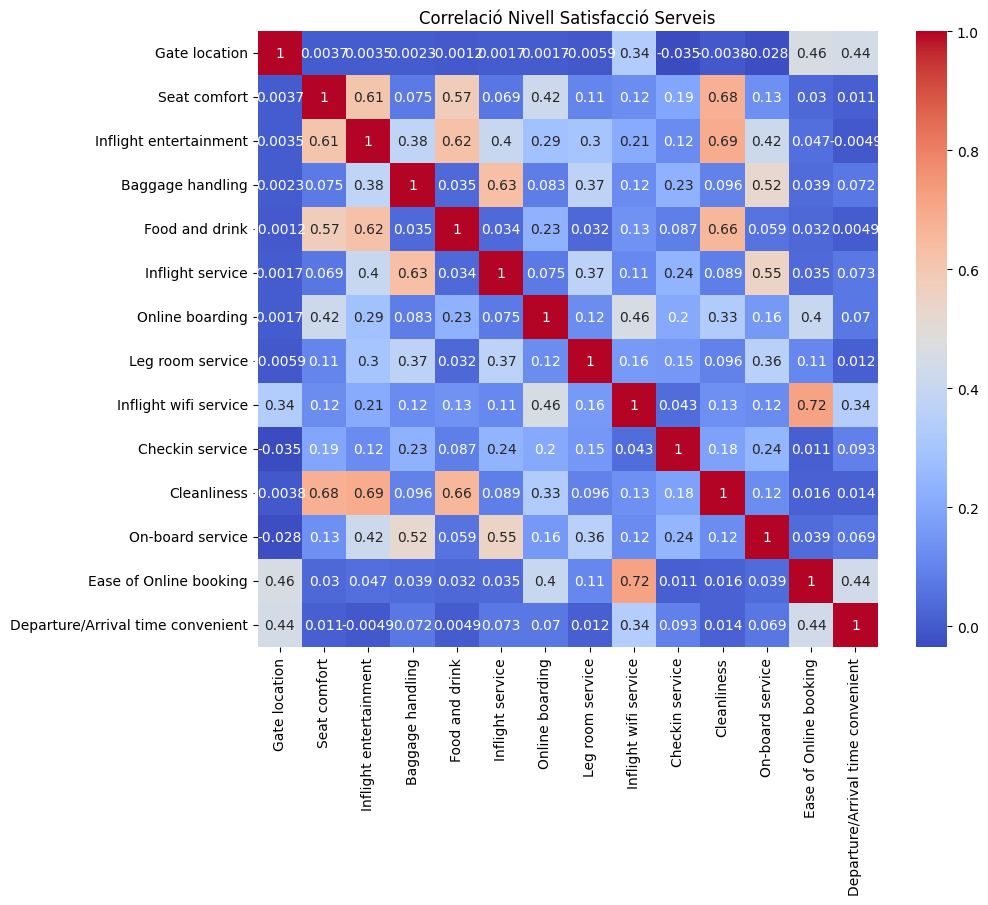

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[lvlcols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlació Nivell Satisfacció Serveis")
plt.show()

La matriu de correlació revela correlacions significatives entre diverses característiques (60%-70%). No obstant això, fusionar variables correlacionades no sempre és el més indicat: aquestes correlacions sovint reflecteixen l'**efecte Halo**, un biaix cognitiu on la percepció positiva d'un atribut predominant eleva artificialment la valoració dels altres.

Per exemple, *Cleanliness* correlaciona fortament amb *Seat comfort* (0.68) i *Inflight entertainment* (0.69). Un entorn net genera benestar que pot emmascarar deficiències en altres àrees. Mantenir-les independents permet discriminar si l'aerolínia requereix inversions diferenciades (manteniment vs. tecnologia).

S'agrupen les variables de satisfacció seguint una lògica de negoci i agregant-les amb la mitjana per a cada grup:

| Columnes originals | Grup |
|--------------------|------|
| Baggage handling</br>Checkin service</br>Inflight service | Logistic |
| Seat comfort</br>Leg room service</br>On-board service | Comfort |
| Ease of Online booking</br>Inflight wifi service</br>Online boarding | Online |

In [10]:
groups = [
  ("Logistic", ["Baggage handling", "Checkin service", "Inflight service"]),
  ("Comfort", ["Seat comfort", "Leg room service", "On-board service"]),
  ("Online", ["Ease of Online booking", "Inflight wifi service", "Online boarding"])
]
for name, group in groups:
  X_train[name] = X_train[group].mean(axis=1)
  X_test[name] = X_test[group].mean(axis=1)
  X_train = X_train.drop(columns=group)
  X_test = X_test.drop(columns=group)
  lvlcols = list(set(lvlcols) - set(group)) + [name]
X_train.head()

,Age,Flight Distance,Departure/Arrival time convenient,Gate location,Food and drink,Inflight entertainment,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Gender_Male,Class_Business,Class_Eco,Class_Eco Plus,Logistic,Comfort,Online
0,13,460,4,1,5,5,5,25,18.0,0.0,1.0,1.0,0.0,0.0,1.0,4.333333,4.000000,3.000000
1,25,235,2,3,1,1,1,1,6.0,1.0,0.0,1.0,1.0,0.0,0.0,2.666667,2.333333,3.000000
2,26,1142,2,2,5,5,5,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.000000,4.000000,3.000000
3,25,562,5,5,2,2,2,11,9.0,0.0,0.0,0.0,1.0,0.0,0.0,2.666667,3.000000,3.000000
4,61,214,3,3,4,3,3,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.333333,4.000000,3.666667


Amb les variables de satisfacció agrupades, s'analitza la correlació de totes les característiques amb la variable objectiu (*satisfaction*) per identificar característiques que no influeixen gaire en el resultat i es puguin descartar.

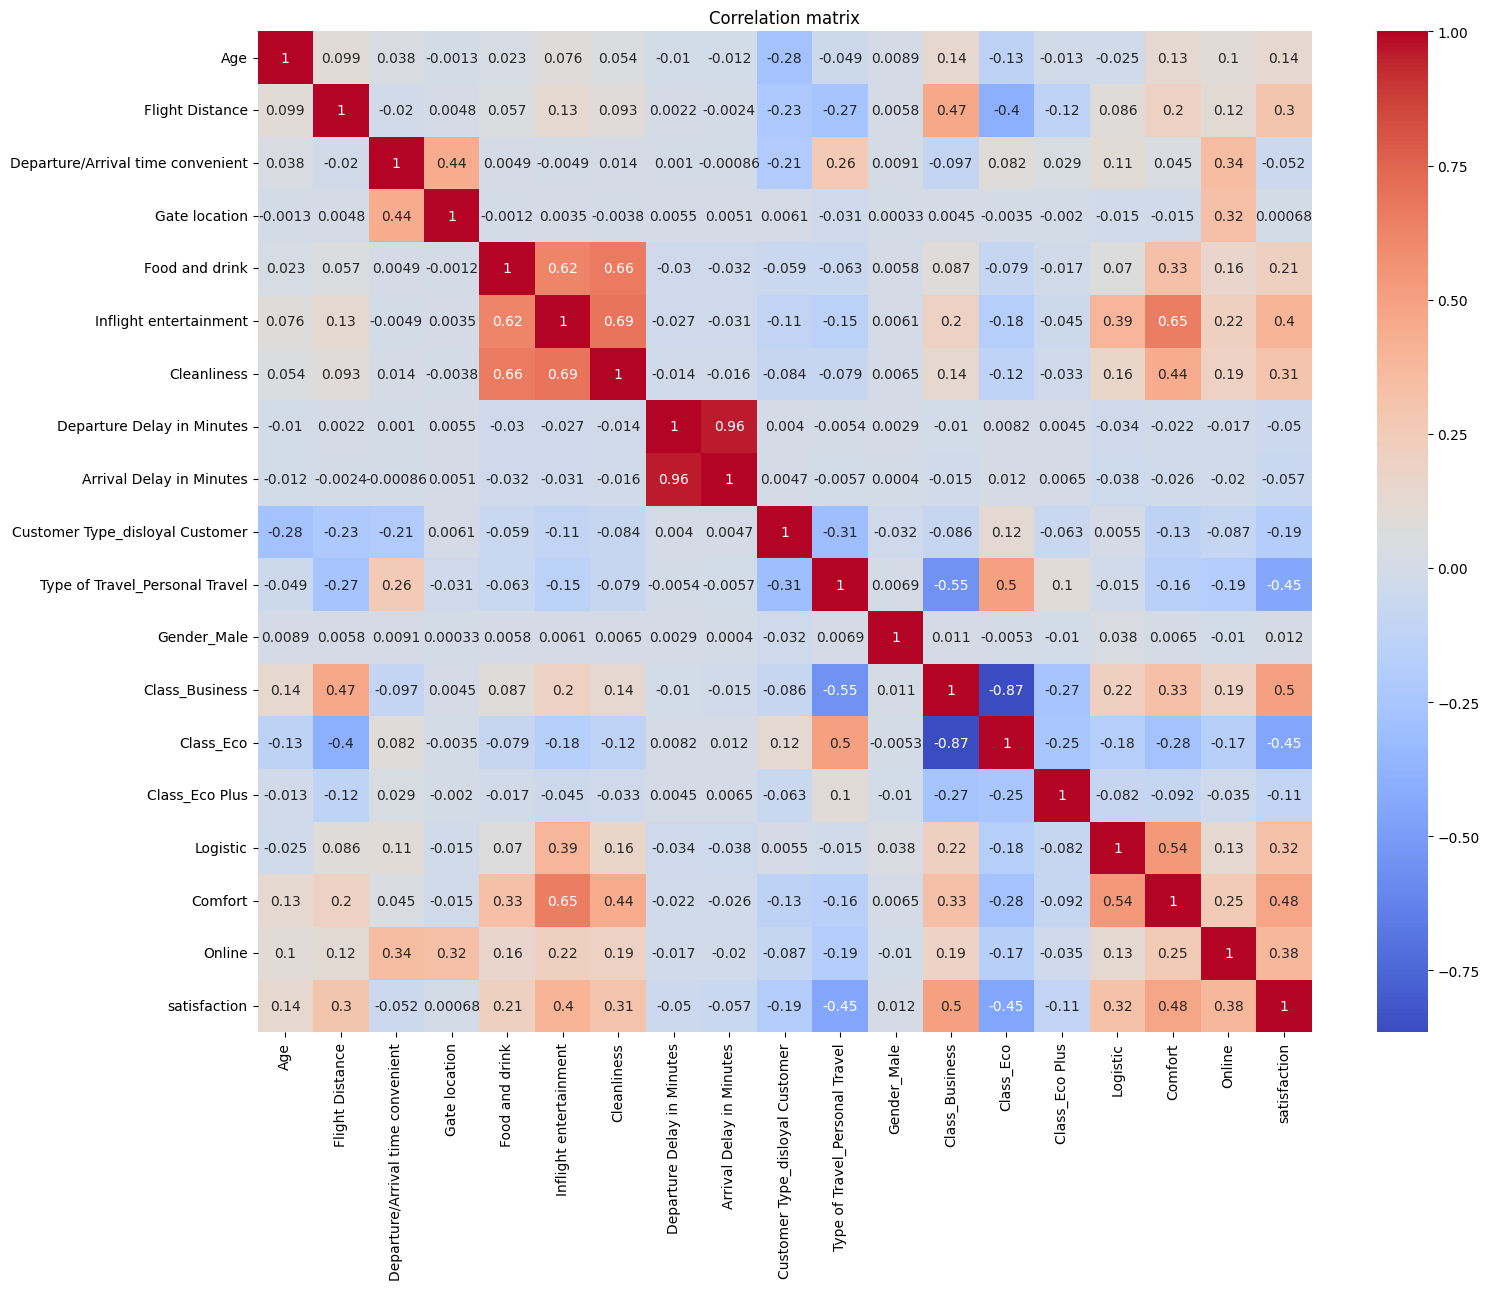

In [11]:
plt.figure(figsize=(17, 13))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

Basant-se en els coeficients de correlació amb *satisfaction*, s'eliminen les variables amb baixa correlació:

- *Departure/Arrival time convenient*
- *Gate location*
- *Departure Delay in Minutes*
- *Arrival Delay in Minutes*
- *Gender_Male*

Es conserven *Age* i *Customer Type* malgrat la seva correlació moderada, ja que constitueixen descriptors demogràfics essencials del passatger (perfil d'edat i fidelització amb l'aerolínia).

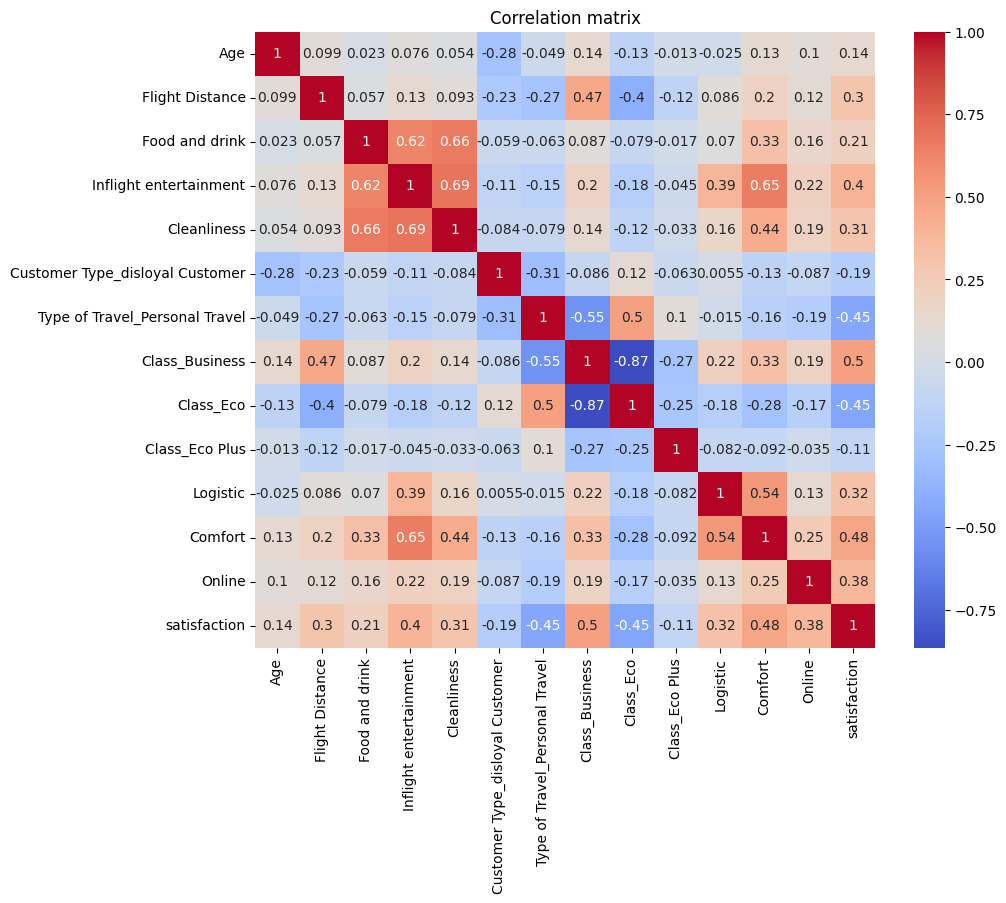

In [12]:
ignore = {
  "Departure/Arrival time convenient",
  "Gate location",
  "Departure Delay in Minutes", "Arrival Delay in Minutes",
  "Gender_Male"
}
X_train = X_train.drop(columns=ignore)
X_test = X_test.drop(columns=ignore)

catcols = list(set(catcols) - ignore)
numcols = list(set(numcols) - ignore)
lvlcols = list(set(lvlcols) - ignore)

plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

# Análisi

L'objectiu d'aquest apartat és analitzar l'estructura de les dades mitjançant tècniques d'aprenentatge no supervisat. L'anàlisi respon a qüestions com:

- La classe de vol (Business, Eco, Eco Plus) influeix significativament en la satisfacció?
- Existeix relació entre la classe de passatger i la distància del vol?

Per identificar perfils de passatgers amb patrons de satisfacció similars, s'aplica l'algorisme de clustering K-Means.

K-Means utilitza la distància euclidiana per assignar punts als centroides. Això implica que variables amb rangs numèrics més amplis dominen el càlcul de distàncies. Per garantir una contribució equitativa de totes les característiques, s'aplica estandardització (*StandardScaler*) que transforma cada variable a mitjana 0 i desviació estàndard 1.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"X_train_scaled shape: {X_train_scaled.shape}")

X_train_scaled shape: (103904, 13)


La selecció del nombre òptim de clusters es realitza mitjançant el mètode del colze (*elbow method*). S'executa K-Means per a $k \in [1, 20]$ i es calcula el WCSS (*Within-Cluster Sum of Squares*; com d'aprop es troben les dades del centre de cada grup) per a cada configuració.

Un WCSS baix indica clusters compactes i ben definits; un WCSS alt suggereix potser facin falta més particions. El punt òptim es troba on l'increment de $k$ deixa de produir reduccions significatives del WCSS. S'estableix un llindar del 5% de millora relativa com a criteri de tall.

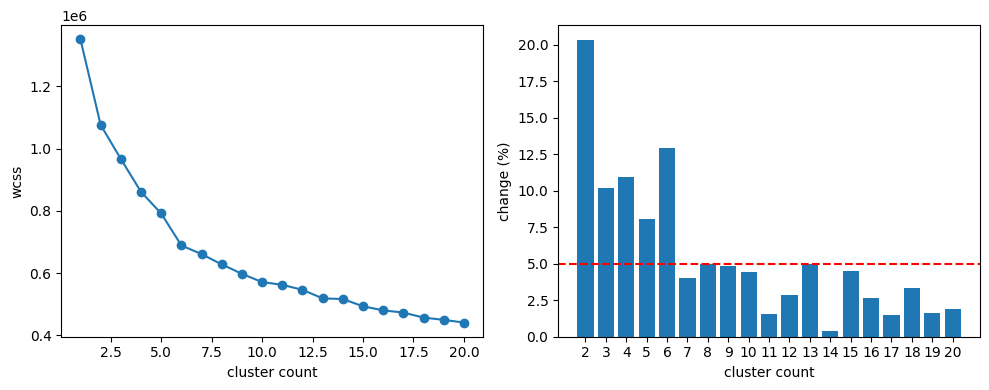

 1 ->  2 :  20.34%
 2 ->  3 :  10.17%
 3 ->  4 :  10.92%
 4 ->  5 :   8.07%
 5 ->  6 :  12.96%
 6 ->  7 :   4.06%
 7 ->  8 :   4.97%
 8 ->  9 :   4.83%
 9 -> 10 :   4.44%
10 -> 11 :   1.54%
11 -> 12 :   2.86%
12 -> 13 :   5.01%
13 -> 14 :   0.41%
14 -> 15 :   4.52%
15 -> 16 :   2.62%
16 -> 17 :   1.52%
17 -> 18 :   3.37%
18 -> 19 :   1.60%
19 -> 20 :   1.92%


In [14]:
from sklearn.cluster import KMeans

cnt = np.arange(1, 20 + 1)
wcss = np.zeros(len(cnt))
for i in cnt:
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X_train_scaled)
  wcss[i-1] = kmeans.inertia_

change_cnt = np.concat([cnt[:-1].reshape(-1, 1), cnt[1:].reshape(-1, 1)], axis=1)
change_pct = (wcss[:-1] - wcss[1:]) / wcss[:-1] * 100

fig, (ax_wcss, ax_change) = plt.subplots(1, 2, figsize=(5 * 2, 4))

ax_wcss.plot(cnt, wcss, marker="o")
ax_wcss.set_xlabel("cluster count")
ax_wcss.set_ylabel("wcss")

ax_change.bar(cnt[1:], change_pct)
ax_change.set_xticks(cnt[1:])
ax_change.set_xlabel("cluster count")
ax_change.set_ylabel("change (%)")
ax_change.axhline(y=5, color="red", linestyle="--")

plt.tight_layout()
plt.show()

for (c1, c2), p in zip(change_cnt, change_pct): print(f"{c1:2d} -> {c2:2d} : {p:6.2f}%")

La corba del WCSS presenta un decreixement pronunciat inicial que s'estabilitza progressivament. Aplicant el criteri del 5% de millora relativa, el nombre mínim de clusters és 7. No obstant això, l'anàlisi de la distribució de satisfacció per cluster revela que amb $k=7$ només un cluster presenta satisfacció elevada (>50%), mentre que amb $k=8$ s'obtenen dos clusters amb aquest nivell. Com que aquest grup extra amb satisfacció elevada pot aportar informació important a l'hora d'entendre els perfils de passatgers satisfets es selecciona $k=8$.

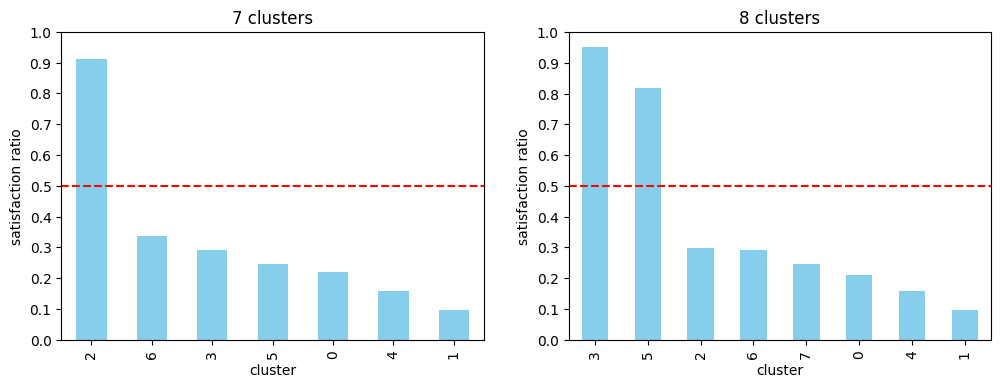

In [15]:
def kmeans_satisfaction(n_clusters, ax, title):
  kmeans = KMeans(n_clusters=n_clusters, random_state=42)
  cluster = pd.concat([X_train, y_train], axis=1)
  cluster["cluster"] = kmeans.fit_predict(X_train_scaled)
  satisfaction_per_cluster = cluster.groupby("cluster")["satisfaction"].mean().sort_values(ascending=False)
  satisfaction_per_cluster.plot(kind="bar", color="skyblue", ax=ax)
  ax.axhline(y=0.5, color="red", linestyle="--")
  ax.set_yticks(np.arange(0.0, 1.1, 0.1))
  ax.set_ylabel("satisfaction ratio")
  ax.set_title(title)
  return cluster

fig, (ax_7, ax_8) = plt.subplots(1, 2, figsize=(6 * 2, 4))
kmeans_satisfaction(7, ax_7, "7 clusters")
kmeans_satisfaction(8, ax_8, "8 clusters")
plt.show()

Per visualitzar la relació entre característiques dels clusters i satisfacció, es genera un *scatter plot* on cada punt representa un cluster. La mida del punt codifica el nombre de passatgers i el color indica el nivell de satisfacció (verd = alta, vermell = baixa).

Aquesta representació permet identificar patrons: per exemple, si els viatgers de negocis amb vols de llarga distància s'agrupen en clusters d'alta satisfacció.

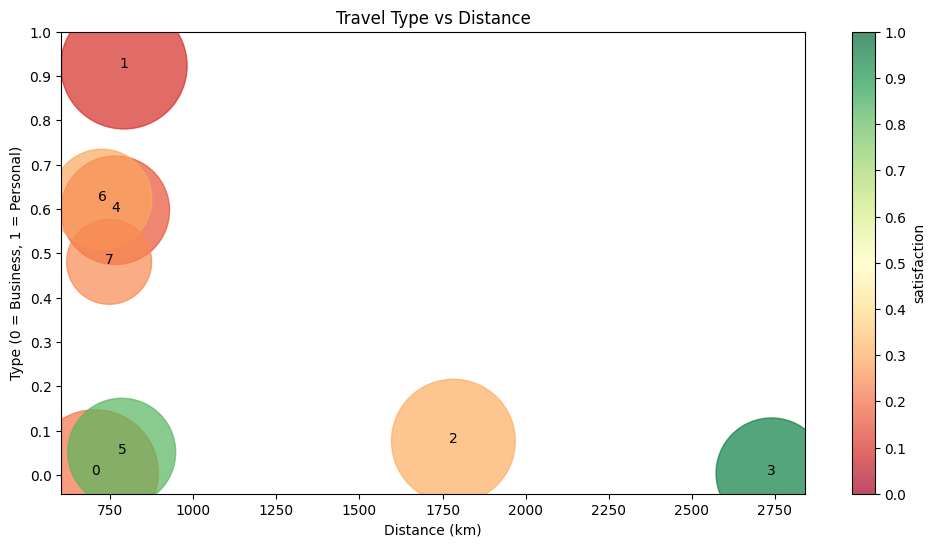

In [16]:
cluster = kmeans_satisfaction(8, ax_8, "8 clusters")
summary = cluster.groupby("cluster").mean()

xcol = "Flight Distance"
ycol = "Type of Travel_Personal Travel"
x, y = summary[xcol], summary[ycol]

fig, ax = plt.subplots(figsize=(12, 6))
scat = ax.scatter(x, y,
            s=cluster["cluster"].value_counts() * 0.5, c=summary["satisfaction"],
            vmin=0.00, vmax=1.00,
            cmap="RdYlGn", alpha=0.70)
for i, txt in enumerate(summary.index):
  x, y = summary[xcol][i], summary[ycol][i]
  ax.annotate(txt, xy=(x, y), xytext=(-3, -3), textcoords="offset points", ha="left", va="bottom")
cbar = fig.colorbar(scat, label="satisfaction")
cbar.set_ticks(np.arange(0, 1.1, 0.1))

ax.set_title("Travel Type vs Distance")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Type (0 = Business, 1 = Personal)")
ax.set_yticks(np.arange(0, 1.10, 0.10))
plt.show()

El gràfic evidencia una separació clara segons el tipus de viatge. Els clusters amb alta satisfacció (verds) es concentren a la zona inferior (*Type of Travel* ≈ 0, viatgers de negocis), mentre que els de baixa satisfacció (vermells) predominen a la zona superior (viatgers personals).

No obstant això, alguns clusters de negocis presenten baixa satisfacció. Per explicar aquesta anomalia, s'analitzen les puntuacions de servei d'aquests clusters.

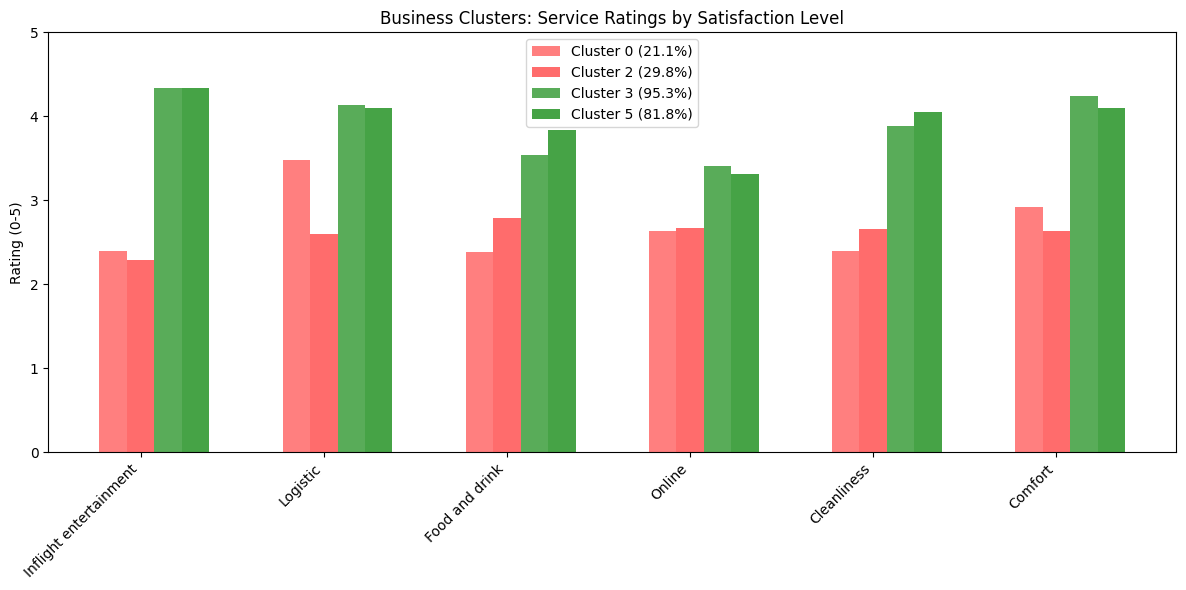

In [17]:
business_clusters = summary[summary["Type of Travel_Personal Travel"] < 0.2].copy()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(lvlcols))
width = 0.15

for i, (idx, row) in enumerate(business_clusters.iterrows()):
  color = "green" if row["satisfaction"] > 0.5 else "red"
  alpha = 0.5 + 0.3 * (i / len(business_clusters))
  ax.bar(x + i * width, [row[col] for col in lvlcols], width,
         label=f"Cluster {idx} ({row['satisfaction']:.1%})", color=color, alpha=alpha)

ax.set_xticks(x + width)
ax.set_xticklabels(lvlcols, rotation=45, ha="right")
ax.set_ylabel("Rating (0-5)")
ax.set_ylim(0, 5)
ax.set_title("Business Clusters: Service Ratings by Satisfaction Level")
ax.legend()
plt.tight_layout()
plt.show()

El gràfic de barres compara les puntuacions de servei entre clusters de viatgers de negocis. Les barres verdes corresponen a clusters amb satisfacció superior al 50%; les vermelles, a clusters amb satisfacció inferior.

Els clusters de negocis amb baixa satisfacció presenten puntuacions uniformement baixes (~2-3 sobre 5) en totes les categories, mentre que els d'alta satisfacció superen 3.5 en pràcticament totes. Això demostra que **el tipus de viatge no és l'únic determinant de la satisfacció**: dins dels viatgers de negocis, la qualitat percebuda dels serveis és el factor diferenciador clau.

Anem a fer el mateix anàlisi per a la la resta de clusters: els viatgers personals.

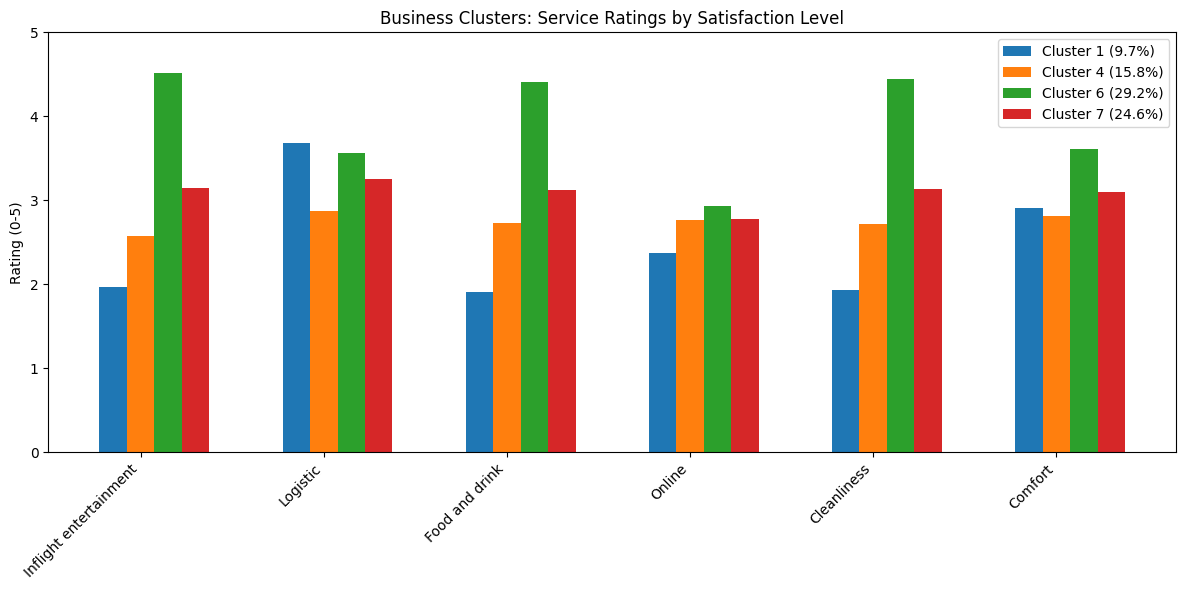

In [18]:
clusters = summary[summary["Type of Travel_Personal Travel"] > 0.2].copy()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(lvlcols))
width = 0.15

for i, (idx, row) in enumerate(clusters.iterrows()):
  ax.bar(x + i * width, [row[col] for col in lvlcols], width,
         label=f"Cluster {idx} ({row['satisfaction']:.1%})")

ax.set_xticks(x + width)
ax.set_xticklabels(lvlcols, rotation=45, ha="right")
ax.set_ylabel("Rating (0-5)")
ax.set_ylim(0, 5)
ax.set_title("Business Clusters: Service Ratings by Satisfaction Level")
ax.legend()
plt.tight_layout()
plt.show()

El gràfic de barres per als clusters de viatgers personals revela un patró consistent: tots els clusters presenten satisfacció inferior al 30%, independentment de les puntuacions de servei. No obstant això, s'observa una relació clara on els clusters amb puntuacions de servei més elevades (>3) assoleixen nivells de satisfacció propers al 30%, mentre que els clusters amb puntuacions baixes (~2-2.5) no superen el 15%.

Aquesta relació confirma que, tot i que el tipus de viatge personal predisposa a una menor satisfacció global, **la qualitat percebuda dels serveis continua sent un factor significatiu**.

# Selecció hiperparàmetres i entrenament

En aquesta secció s'entrenen i comparen els cinc models requerits: Perceptró, Regressió Logística, SVM, Arbre de Decisió i Random Forest.

Per a cada model es segueix el següent procés:
1. **Selecció d'hiperparàmetres**: S'utilitza `GridSearchCV` amb validació creuada amb $k=5$ per trobar la millor combinació d'hiperparàmetres.
2. **Entrenament**: El model es torna a entrenar amb els millors hiperparàmetres trobats.
3. **Avaluació**: S'avalua el model amb múltiples mètriques per a qualificar el seu rendiment.

Per aquest problema de classificació binària (satisfet o no satisfet) s'utilitzen les següents mètriques:

- **Accuracy**: Proporció de prediccions correctes.
- **Precision**: Important per evitar falsos positius: no volem dir que un passatger està satisfet quan realment no ho està.
- **Recall**: Important per detectar tots els passatgers insatisfets i poder actuar per millorar la seva experiència.
- **F1-Score**: Harmònica entre precision i recall, útil per tenir una visió global del rendiment.

In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
import joblib
import os

Per a cada model s'han seleccionat els següents hiperparàmetres (s'ha intentat escollir els més rellevants segons la seva influència en el rendiment):

### Perceptró

**`penalty`** (tipus de regularització): Defineix com es penalitzen els pesos del model.
- `None`: Sense regularització, el model és lliure de créixer sense restriccions (risc d'overfitting).
- `l2`: Penalitza la suma dels pesos al quadrat.
- `l1`: Penalitza la suma del valor absolut dels pesos.
- `elasticnet`: Combina L1 i L2, aprofita els avantatges de tots dos.

**`alpha`** (força de regularització): Controla l'overfitting penalitzant pesos grans.
- Valors més baixos permeten al model aprendre patrons més complexos però poden provocar overfitting.
- Valors més alts forcen més simplicitat al model i milloren la generalització.

### Regressió Logística

**`C`** (inversa de la força de regularització): És l'invers d'`alpha`.
- Valors més baixos forcen més simplicitat al model i milloren la generalització.
- Valors més alts permeten al model aprendre patrons més complexos però poden provocar overfitting.

**`solver`** (algoritme d'optimització): Afecta la velocitat de convergència i quines penalitats suporta.
- `lbfgs`: (Limited-memory Broyden-Fletcher-Goldfarb-Shanno) eficient per datasets petits/mitjans, només suporta L2.
- `liblinear`: (Library for Large Linear Classification) bo per datasets petits, suporta L1 i L2.
- `saga`: (Stochastic Average Gradient Augmented) eficient per datasets grans, suporta L1, L2 i elasticnet.

### SVM (Support Vector Machine)

**`C`** (penalització d'errors): Controla el balanç entre maximitzar el marge i minimitzar errors de classificació.
- Valors més baixos prioritzen un marge ampli i toleren més errors.
- Valors més alts prioritzen classificar correctament i toleren menys error, però pot provocar overfitting.

**`kernel`** (funció del kernel): Defineix com es mapegen les dades a un espai dimensional superior.
- `linear`: Decisió lineal, assumeix que les dades són linealment separables (ràpid, simple).
- `rbf` (Radial Basis Function): Crea fronteres circulars/el·líptiques, capta relacions no lineals complexes.
- `poly` (Polinomial): Crea fronteres polinòmiques, útil per relacions d'interacció entre característiques.

### Arbre de Decisió

**`max_depth`** (profunditat màxima): Limita quantes divisions pot fer l'arbre.
- Valors més baixos creen arbres superficials i simples amb menys risc d'overfitting, però poden no capturar patrons complexos.
- Valors més alts permeten arbres profunds que capturen relacions complexes, però amb més risc d'overfitting.
- `None`: L'arbre creix sense límit. Això implica un alt risc d'overfitting.

**`min_samples_split`** (mínim de mostres per dividir un node): Controla quan un node es pot dividir.
- Valors més baixos permeten divisions molt granulars i aprenen soroll, però amb risc d'overfitting.
- Valors més alts forcen divisions més robustes basades en més dades (millor generalització).

### Random Forest

**`n_estimators`** (nombre d'arbres): Més arbres redueixen la variància i milloren l'estabilitat.
- Valors més baixos creen models més ràpids però menys estables.
- Valors més alts creen models més estables i robustos però més lents.

**`max_depth`** (profunditat màxima de cada arbre): Controla la complexitat individual de cada arbre.
- Valors més baixos creen arbres simples.
- Valors més alts permeten arbres complexos que capturen patrons detallats.
- `None`: Arbres sense límit.

In [20]:
models_params = {
    "Perceptron": (
        Perceptron(max_iter=1000, random_state=42),
        {
            "alpha": [0.0001, 0.001, 0.01, 0.1],
            "penalty": [None, "l2", "l1", "elasticnet"]
        }
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "liblinear", "saga"]
        }
    ),
    "SVM": (
        SVC(random_state=42),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf", "poly"]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None]
        }
    )
}

cache_dir = "model_cache"
cache_file = os.path.join(cache_dir, "results.pkl")

if os.path.exists(cache_file):
    print("=" * 60)
    print("Loading cached results...")
    print("=" * 60)
    results = joblib.load(cache_file)
    print(f"Loaded {len(results)} models from cache")
else:
    os.makedirs(cache_dir, exist_ok=True)

    results = {}

    for name, (model, params) in models_params.items():
        print(f"{"-"*60}")
        print(name)
        print(f"{"-"*60}")
    
        start = time.perf_counter()
        gs = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
        gs.fit(X_train_scaled, y_train)
        end = time.perf_counter()
    
        best_model = gs.best_estimator_
        y_train_pred = best_model.predict(X_train_scaled)
        y_test_pred = best_model.predict(X_test_scaled)
    
        results[name] = {
            "params": gs.best_params_,
            "cv_acc": gs.best_score_,
            "train_acc": accuracy_score(y_train, y_train_pred),
            "test_acc": accuracy_score(y_test, y_test_pred),
            "precision": precision_score(y_test, y_test_pred),
            "recall": recall_score(y_test, y_test_pred),
            "f1": f1_score(y_test, y_test_pred),
            "y_test_pred": y_test_pred,
            "model": best_model
        }
    
        print()
        print(f"search time: {end - start:6.4f}s")
        print(f"best params: {results[name]["params"]}")
        print(f"     cv acc: {results[name]["cv_acc"]:.4f}")
        print(f"  train acc: {results[name]["train_acc"]:.4f}")
        print(f"   test acc: {results[name]["test_acc"]:.4f}")
        print()
    
    print("=" * 60)
    print(f"Saving results to cache: {cache_file}")
    print("=" * 60)
    joblib.dump(results, cache_file)

results = (pd.DataFrame.from_dict(results, orient="index").reset_index()
                       .rename(columns={"model": "instance"})
                       .rename(columns={"index": "model"})
                       .set_index("model"))
results

Loading cached results...
Loaded 5 models from cache


,params,cv_acc,train_acc,test_acc,precision,recall,f1,y_test_pred,instance
model,,,,,,,,,
Perceptron,"{'alpha': 0.001, 'penalty': 'elasticnet'}",0.824165,0.827533,0.822952,0.769572,0.851706,0.808558,"[1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","Perceptron(alpha=0.001, penalty='elasticnet', ..."
Logistic Regression,"{'C': 0.01, 'solver': 'lbfgs'}",0.862296,0.862286,0.856406,0.849504,0.817767,0.833333,"[1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","LogisticRegression(C=0.01, max_iter=1000, rand..."
SVM,"{'C': 10, 'kernel': 'rbf'}",0.925585,0.929983,0.926509,0.926888,0.903885,0.915242,"[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, ...","SVC(C=10, random_state=42)"
Decision Tree,"{'max_depth': 15, 'min_samples_split': 10}",0.922717,0.949550,0.925162,0.930463,0.896518,0.913176,"[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","DecisionTreeClassifier(max_depth=15, min_sampl..."
Random Forest,"{'max_depth': 20, 'n_estimators': 200}",0.933670,0.981993,0.933516,0.940299,0.906077,0.922871,"[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...","(DecisionTreeClassifier(max_depth=20, max_feat..."


## Resum dels resultats

| Model               | Temps (s) | Millors hiperparàmetres                  | `cv_acc` |
|---------------------|-----------|------------------------------------------|----------|
| Perceptró           |       2.1 | `alpha=0.001`</br>`penalty='elasticnet'` |   0.8241 |
| Regressió Logística |       1.0 | `C=0.01`</br>`solver='lbfgs'`            |   0.8622 |
| SVM                 |       531 | `C=10`</br>`kernel='rbf'`                |   0.9255 |
| Arbre de decisió    |       2.0 | `max_depth=15`</br>`min_samples_split=10`|   0.9227 |
| Random Forest       |      33.5 | `max_depth=20`</br>`n_estimators=200`    |   0.9336 |

En quant al temps d'execució tenim:

- **Models lineals** (Perceptró: 2.1s, Regressió Logística: 1.0s): Molt ràpids al ser models molt simples.
- **Arbre de Decisió** (2.0s): Ràpid perquè cada divisió és una operació simple de comparació.
- **Random Forest** (33.5s): bastant més lent que un arbre individual perquè entrena molts més arbres.
- **SVM** (531s = 8 minuts amb 58 segons): extremadament més lent que la resta de models, especialment degut al kernel no lineal RBF i la quantitat elevada de mostres (>100,000).

I pel que fa als millors hiperparàmetres:

Els models lineals són els que tenen els pitjors `cv_acc`, cosa que apunta a que la satisfacció està relacionada amb les altres dades de forma no lineal. A més, això està recolzat pel fet que el millor kernel de SVM és rbf, que és no lineal.

Els models basats en arbres són els que tenen els millors `cv_acc`. Ambdós models han escollit la profunditat més alta permesa, sense escollir una profunditat sense límit, cosa que els fa molt especialitzats en les dades (possible overfitting). A més, el Random Forest ha seleccionat 200 arbres de decisió, possiblement per permetre que cada un s'especialitzi amb una part de les dades i millorar la predicció a través de l'ensemble averaging.

**Nota**: s'ha afegit una cache, localitzat al fitxer `model_cache/results.pkl`, dels models entrenats per a evitar temps d'execució llargs cada vegada que s'obri el projecte de nou. Si es vol invalidar la cache és suficient amb eliminar el fitxer o tot el directori que el conté.

## Visualització comparativa

A continuació es presenten gràfics per comparar el rendiment dels models i detectar possibles problemes com l'overfitting.

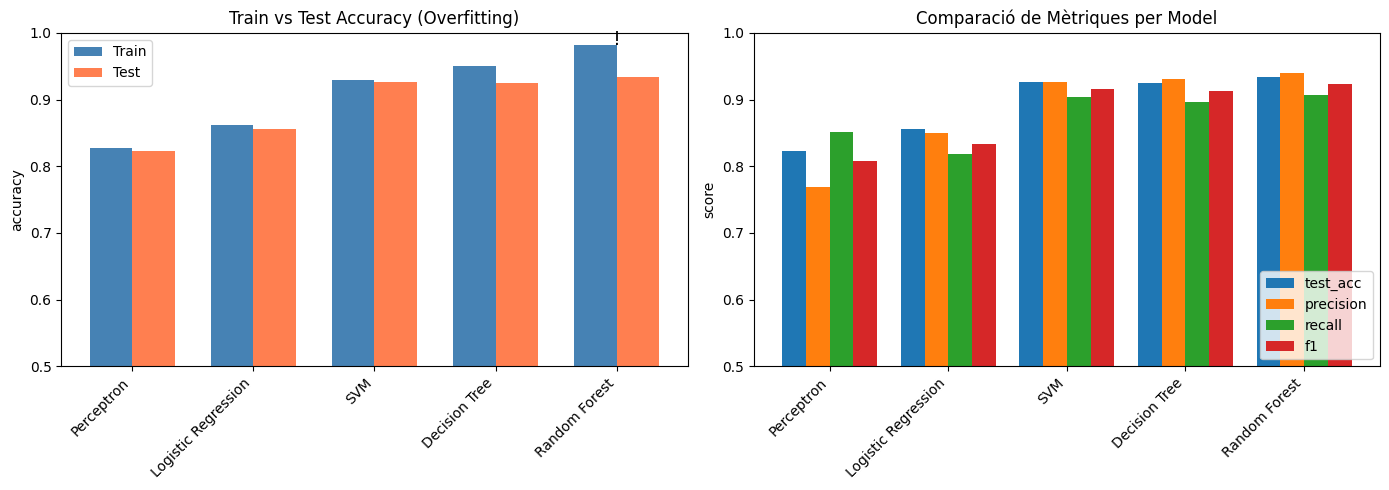

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(results))
width = 0.35
models_names = results.index.values

ax1 = axes[0]
train_acc = [results["train_acc"][m] for m in models_names]
test_acc = [results["test_acc"][m] for m in models_names]

bars1 = ax1.bar(x - width/2, train_acc, width, label="Train", color="steelblue")
bars2 = ax1.bar(x + width/2, test_acc, width, label="Test", color="coral")

ax1.set_ylabel("accuracy")
ax1.set_title("Train vs Test Accuracy (Overfitting)")
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha="right")
ax1.legend()
ax1.set_ylim(0.5, 1.0)

for i, (tr, te) in enumerate(zip(train_acc, test_acc)):
  if tr - te >= 0.04:
    ax1.annotate("!", xy=(i, tr), fontsize=14, ha="center")

ax2 = axes[1]
metrics = ["test_acc", "precision", "recall", "f1"]
x2 = np.arange(len(models_names))
width = 0.2

for i, metric in enumerate(metrics):
  values = results[metric].values
  ax2.bar(x2 + i * width, values, width, label=metric)

ax2.set_ylabel("score")
ax2.set_title("Comparació de Mètriques per Model")
ax2.set_xticks(x2 + width * 1.5)
ax2.set_xticklabels(models_names, rotation=45, ha="right")
ax2.legend(loc="lower right")
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

**Gràfic comparativa accuracy entre train i test (esquerre)**

Els models lineals (Perceptró i Regressió Logística) mostren un accuracy inferior al 85% mentre que els models no lineals (SVM, Decision Tree, Random Forest) superen el 90%. Això confirma que el nivell de satisfacció depèn de relacions no lineals entre característiques. En quant a l'overfitting, Random Forest mostra la diferència train-test més gran degut als 200 arbres profunds que memoritzen patrons específics. Decision Tree també presenta overfitting, però més baix. SVM amb kernel RBF és el model més equilibrat gràcies a la regularització del paràmetre `C=10` que penalitza errors dins del marge.

**Gràfic comparativa mètriques (dreta)**

El Perceptró mostra un desequilibri notable amb *recall* alt però *precision* baixa, indicant que prediu "satisfet" massa sovint (molts falsos positius). La Regressió Logística equilibra millor *precision* i *recall* probablement gràcies a la seva regularització forta (`C=0.01`). En quant als models no lineals, tots tres mantenen les quatre mètriques per damunt del 90% i ben equilibrades.

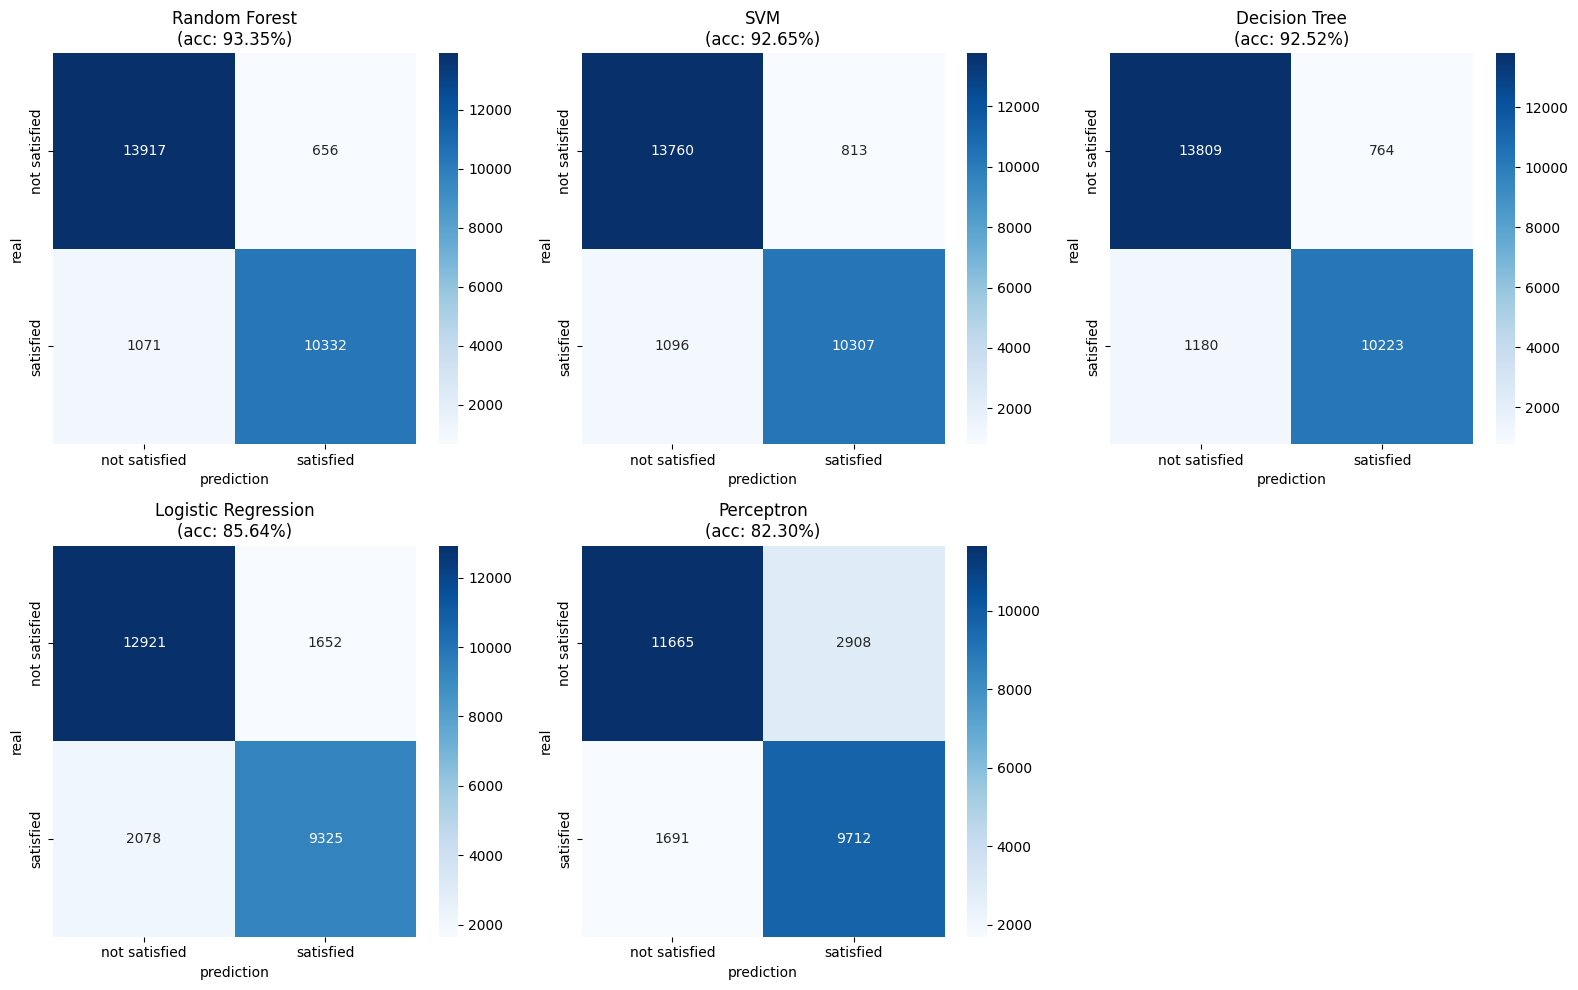

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

sorted_results = results.sort_values("test_acc", ascending=False)

for i, (model_name, row) in enumerate(sorted_results.iterrows()):
    ax = axes[i]
    cm = confusion_matrix(y_test, row["y_test_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["not satisfied", "satisfied"],
                yticklabels=["not satisfied", "satisfied"])
    ax.set_title(f"{model_name}\n(acc: {row['test_acc']:.2%})")
    ax.set_ylabel("real")
    ax.set_xlabel("prediction")

axes[-1].axis("off")

plt.tight_layout()

Els models no lineals presenten matrius de confusió similars, coherent amb els seus valors d'accuracy pràcticament equivalents. Els tres models tenen una tendència a minimitzar els falsos positius a costa d'incrementar els falsos negatius.

Els models lineals mostren valors superiors a les cel·les fora de la diagonal principal, coherent amb els seus valors d'accuracy menors. La Regressió Logística manté el mateix patró que els models no lineals (preferència per falsos negatius), mentre que el Perceptró presenta el comportament invers (preferència per falsos positius).

Aquesta diferència té implicacions pràctiques rellevants: des de la perspectiva de l'aerolínia, els falsos positius (classificar com a satisfet un passatger insatisfet) poden ser més perjudicial que els falsos negatius, ja que impedeixen identificar clients que requereixen atenció. En aquest context, el patró del Perceptró resultaria menys adequat.

Finalment, gràcies als models basats en arbres, podem visualitzar la importància que han assignat a cada una de les característiques.

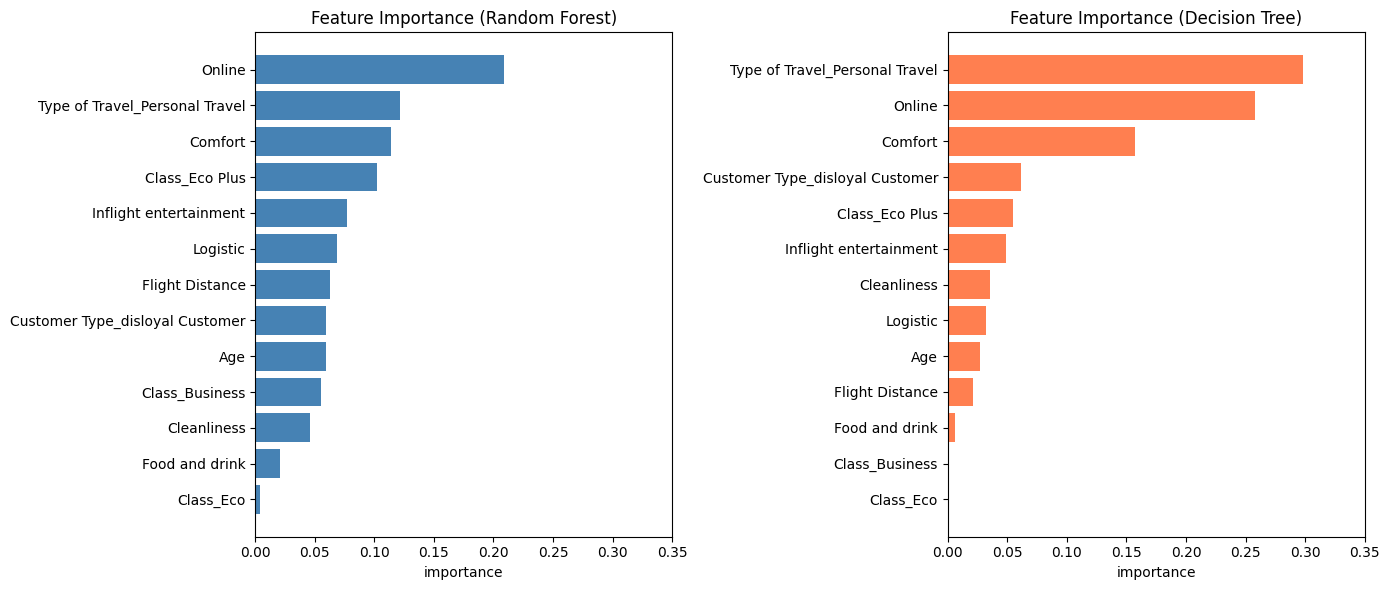

In [27]:
rf_model = results["instance"]["Random Forest"]
dt_model = results["instance"]["Decision Tree"]

rf_importance = pd.DataFrame({
  "feature": X_train.columns,
  "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=True)

dt_importance = pd.DataFrame({
  "feature": X_train.columns,
  "importance": dt_model.feature_importances_
}).sort_values("importance", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(rf_importance["feature"], rf_importance["importance"], color="steelblue")
ax1.set_xlim(0, 0.35)
ax1.set_xlabel("importance")
ax1.set_title("Feature Importance (Random Forest)")

ax2.barh(dt_importance["feature"], dt_importance["importance"], color="coral")
ax2.set_xlim(0, 0.35)
ax2.set_xlabel("importance")
ax2.set_title("Feature Importance (Decision Tree)")

plt.tight_layout()
plt.show()

Ambdós models coincideixen en les tres característiques més rellevants: *Type of Travel*, *Online* i *Comfort*. Això és coherent amb l'anàlisi de clustering realitzat anteriorment, on s'ha identificat que el tipus de viatge és el principal factor diferenciador de satisfacció, i que les puntuacions de servei són un factor determinant per a la satisfacció dins de cada tipus de viatger.

El Decision Tree concentra la importància en poques característiques: *Type of Travel* acumula aproximadament el 30% del pes total, mentre que la resta de variables tenen contribucions significativament menors. Aquest comportament és característic dels arbres de decisió, que utilitzen un algorisme *greedy*: les primeres divisions es realitzen amb les característiques que maximitzen el guany d'informació.

En canvi, el Random Forest distribueix la importància de forma més uniforme entre totes les característiques. Aquesta diferència s'explica per dos mecanismes inherents a l'algorisme:

1. Cada arbre s'entrena amb un subconjunt aleatori de les dades, el que permet que diferents característiques siguin seleccionades com a primera divisió en arbres diferents.
2. En cada node, només es considera un subconjunt aleatori de característiques, forçant que característiques menys dominants tinguin oportunitats de ser seleccionades.